In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# Ensure project root is importable when notebook is opened from notebooks/
repo_root = Path.cwd().resolve()
if not (repo_root / "diffsim").exists():
    candidate = repo_root.parent
    if (candidate / "diffsim").exists():
        os.chdir(candidate)
        repo_root = candidate

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"Repository root: {repo_root}")

from diffsim.data.flumy_generator import FlumyGenerator, FACIES_NAMES, FACIES_NORMALIZED
from diffsim.data.seismic import generate_rms_from_facies_3d, DEFAULT_ROCK_PROPERTIES

# ── CHANNELASSO_AV colour palette ────────────────────────────────────────────
FACIES_COLORS = {
    0: '#8B6914',  # Overbank  – brown
    1: '#FFD700',  # Channel   – gold
    2: '#90EE90',  # Levee     – light green
    3: '#FFA500',  # Cravasse  – orange
    4: '#2F2F2F',  # Coal      – near-black
    5: '#BC8F8F',  # Others    – rosy brown
}

CMAP6 = mcolors.ListedColormap([FACIES_COLORS[i] for i in range(6)])
NORM6 = mcolors.BoundaryNorm(boundaries=[-0.5 + i for i in range(8)], ncolors=7)

FACIES_DIR = Path("/mnt/sda_data/tharitt/diffsim/data/flumy3d/facies")
RMS_DIR    = Path("/mnt/sda_data/tharitt/diffsim/data/flumy3d/rms")
EXAMPLE    = "ng50_isbx80_seed6.npy"

print("Imports complete.")


Repository root: /home/tharitt/working/DiffSim
Imports complete.


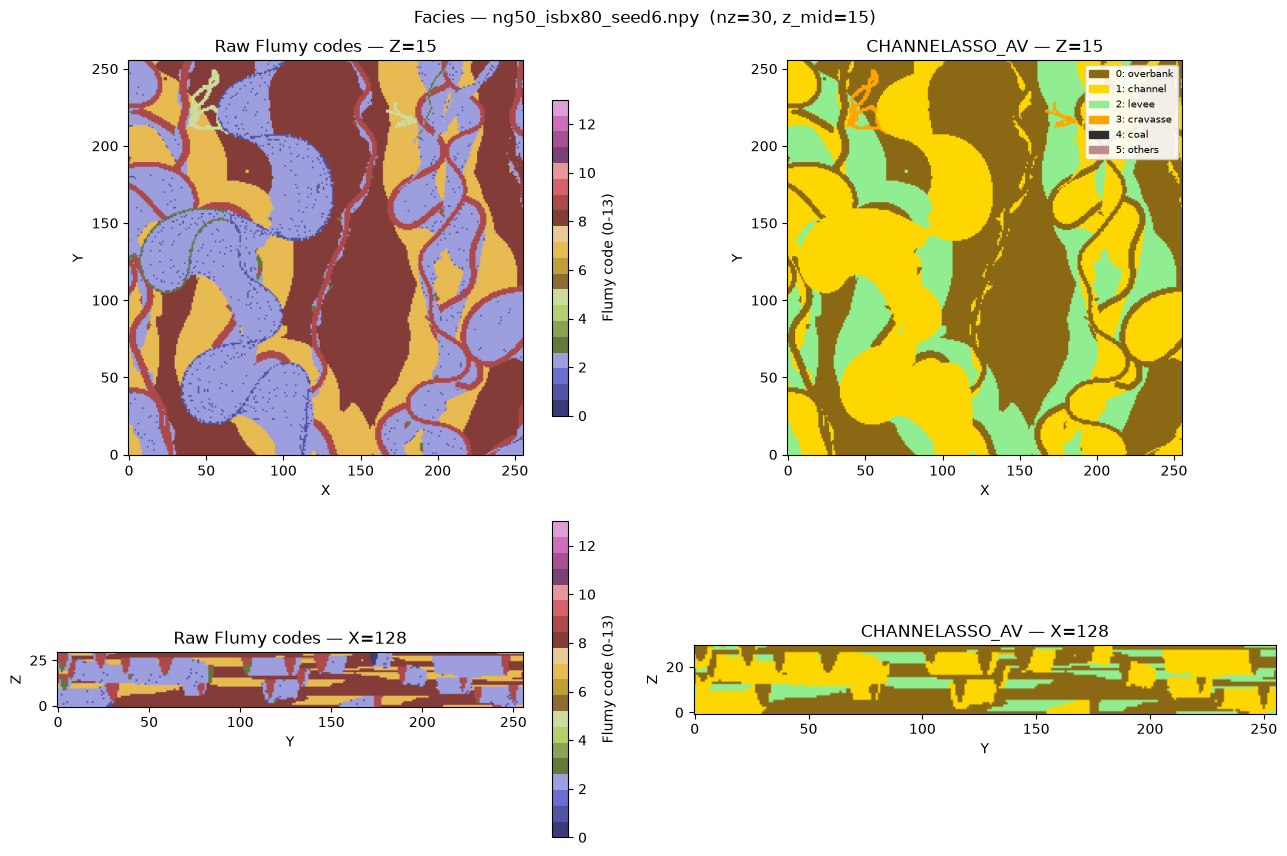

Facies proportions:
  0 overbank  :  930678  (47.3%)
  1 channel   :  690579  (35.1%)
  2 levee     :  340360  (17.3%)
  3 cravasse  :    4463  (0.2%)
  4 coal      :       0  (0.0%)
  5 others    :       0  (0.0%)


In [3]:
# ── Raw Flumy codes (0-13) vs reclassified CHANNELASSO_AV (0-5) ───────────────
facies_raw = np.load(FACIES_DIR / EXAMPLE)
facies_6   = FlumyGenerator.reclassify_facies(facies_raw)

nx, ny, nz = facies_raw.shape
z_mid = nz // 2

legend_patches = [
    mpatches.Patch(color=FACIES_COLORS[k], label=f"{k}: {FACIES_NAMES[k]}")
    for k in range(6)
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f"Facies — {EXAMPLE}  (nz={nz}, z_mid={z_mid})", fontsize=12)

for row, (z, label) in enumerate([(z_mid, f"Z={z_mid}"), (z_mid, f"X={nx//2}")]):
    if row == 0:
        raw_sl  = facies_raw[:, :, z_mid]
        reclass = facies_6[:, :, z_mid]
        xl, yl  = "X", "Y"
    else:
        raw_sl  = facies_raw[nx // 2, :, :].T
        reclass = facies_6[nx // 2, :, :].T
        xl, yl  = "Y", "Z"

    # Raw Flumy codes
    im = axes[row, 0].imshow(raw_sl, origin="lower", cmap="tab20b", vmin=0, vmax=13)
    axes[row, 0].set_title(f"Raw Flumy codes — {label}")
    axes[row, 0].set_xlabel(xl); axes[row, 0].set_ylabel(yl)
    fig.colorbar(im, ax=axes[row, 0], shrink=0.8, label="Flumy code (0-13)")

    # CHANNELASSO_AV (6-class)
    axes[row, 1].imshow(reclass, origin="lower", cmap=CMAP6, norm=NORM6)
    axes[row, 1].set_title(f"CHANNELASSO_AV — {label}")
    axes[row, 1].set_xlabel(xl); axes[row, 1].set_ylabel(yl)

axes[0, 1].legend(handles=legend_patches, loc="upper right",
                  fontsize=7, framealpha=0.9)

plt.tight_layout()
plt.show()

# Print facies proportions
total = facies_6.size
print("Facies proportions:")
for k, name in FACIES_NAMES.items():
    n = (facies_6 == k).sum()
    print(f"  {k} {name:10s}: {n:7d}  ({100*n/total:.1f}%)")


In [ ]:
# ── Generate RMS from reclassified facies block ───────────────────────────────
rng = np.random.default_rng(42)
rms_block = generate_rms_from_facies_3d(
    facies_6,
    rock_properties=DEFAULT_ROCK_PROPERTIES,
    rms_window_half=1,
    noise_level=0.3,
    smooth_sigma=None,  # auto-compute from Fresnel zone
    rng=rng,
)

print(f"facies_6  shape: {facies_6.shape}")
print(f"rms_block shape: {rms_block.shape}  (nz-1 due to reflectivity)")

nx, ny, nz_rms = rms_block.shape
z_mid = nz_rms // 2

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f"Facies vs RMS — {EXAMPLE}", fontsize=12)

for row, (plan_label, fac_sl, rms_sl) in enumerate([
    (f"Z={z_mid}",   facies_6[:, :, z_mid],        rms_block[:, :, z_mid]),
    (f"X={nx//2}",   facies_6[nx//2, :, :].T,      rms_block[nx//2, :, :].T),
]):
    axes[row, 0].imshow(fac_sl, origin="lower", cmap=CMAP6, norm=NORM6)
    axes[row, 0].set_title(f"Facies — {plan_label}")
    axes[row, 0].legend(handles=legend_patches, loc="upper right", fontsize=7, framealpha=0.9)

    im = axes[row, 1].imshow(rms_sl, origin="lower", cmap="gist_rainbow_r")
    axes[row, 1].set_title(f"RMS amplitude — {plan_label}")
    fig.colorbar(im, ax=axes[row, 1], shrink=0.8, label="RMS")

plt.tight_layout()
plt.show()


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [5]:
# ── Load pre-computed RMS cube and compare with facies ────────────────────────
rms_precomp = np.load(RMS_DIR / EXAMPLE)

print(f"Pre-computed RMS shape: {rms_precomp.shape}")

nx, ny, nz_rms = rms_precomp.shape
z_mid = nz_rms // 2

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f"Pre-computed RMS vs Facies — {EXAMPLE}", fontsize=12)

for row, (plan_label, fac_sl, rms_sl) in enumerate([
    (f"Z={z_mid}",   facies_6[:, :, z_mid],        rms_precomp[:, :, z_mid]),
    (f"X={nx//2}",   facies_6[nx//2, :, :].T,      rms_precomp[nx//2, :, :].T),
]):
    axes[row, 0].imshow(fac_sl, origin="lower", cmap=CMAP6, norm=NORM6)
    axes[row, 0].set_title(f"Facies — {plan_label}")
    axes[row, 0].legend(handles=legend_patches, loc="upper right", fontsize=7, framealpha=0.9)

    im = axes[row, 1].imshow(rms_sl, origin="lower", cmap="gist_rainbow_r")
    axes[row, 1].set_title(f"RMS (pre-computed) — {plan_label}")
    fig.colorbar(im, ax=axes[row, 1], shrink=0.8, label="RMS")

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/sda_data/tharitt/diffsim/data/flumy3d/rms/ng50_isbx80_seed6.npy'